# Module for computing and analyzing logarithmic vector fields of central hyperplane arrangements.
- Created: 6 June 2023
- Last modifed: 03 Dec 2025

This module provides functionality to work with the module $D(A)$ of logarithmic vector 
fields along a central hyperplane arrangement $A$. 

**Key features**
- Computing basis elements of $D(A)$
- Application to vector field reconstruction


In [2]:
#%display latex
from IPython.display import Math, display
from matplotlib import pyplot as plt
import sage.misc.latex as sage_latex
import sys
from tqdm.auto import tqdm
from sage.modules.free_module_element import FreeModuleElement_generic_dense as module_elem
from sage.libs.singular.function_factory import singular_function
syz = singular_function("syz")

sys.path.insert(0, './src')
from hyperplane_arrangements import *

# replace the default show function with one that works better in VSCode
import shutil, sys
try:
    original_show = show
except NameError:
    from IPython.display import Markdown, display
    display(Markdown(
        "## ⚠ Wrong Kernel\n\n"
        + "\n".join(f"- {e}" for e in _err)
        + "\n\n**This notebook must be run with the SageMath kernel, not a plain Python kernel.**\n\n"
        "In JupyterLab: *Kernel → Change Kernel → SageMath*\n\n"
        "In VS Code: click the kernel name in the top-right corner and select *SageMath*."
    ))
    raise SystemExit("Switch to the SageMath kernel and re-run.")
else:
    print(f"OK: SageMath kernel (Python {sys.version.split()[0]})")

def vscode_show(*args, **kwargs):
    for expr in args:
        try:
            if hasattr(expr, '_latex_'):
                display(Math(expr._latex_()))
            else:
                display(Math(sage_latex.latex(expr)))
        except Exception as e:
            print(f"LaTeX rendering failed: {e}")
            original_show(expr, **kwargs)
show = vscode_show
print(sage.version.banner)


OK: SageMath kernel (Python 3.12.12)
SageMath version 10.7, Release Date: 2025-08-09


## Fano Plane

In [22]:
# create the matrix corresponding to the Fano plane
seed = [1,1,0,1,0,0,0]
mat = [seed.copy()]
for i in range(len(seed)-1):
    l = seed.pop(0)
    seed.append(l)
    mat.append(seed.copy())
M=matrix(mat)
# an arrangement is represented by a matrix whose row vectors correspond to the linear forms defining the planes
show(M) # M*M.T

# characteristic 0
A=HyperPlaneArr(mat,base_field=QQ)
# minimal set of generators
#print(A.minimal_generators)
# degree sequence of D(A)
print("degree seq over Q",A.degs())

# characteristic 2
A=HyperPlaneArr(mat,base_field=GF(2)) # non-essential
# minimal set of generators
#print(A.minimal_generators)
# degree sequence of D(A)
print("degree seq over F2",A.degs())


<IPython.core.display.Math object>

degree seq over Q [1, 1, 1, 1, 1, 1, 1]
degree seq over F2 [0, 0, 0, 1, 2, 3, 3, 3]


## dim 3, |A|=3, free

In [23]:
# an arrangement is represented by a matrix whose row vectors correspond to the linear forms defining the planes
mat = [[1,0,0],[0,1,0],[0,0,1]]
A=HyperPlaneArr(mat,base_field=QQ)
MG = A.minimal_generators()
#MG=vector_to_derivative(MG)
# minimal set of generators
show("minimal set of module generators of D(A)",MG)
# degree sequence of D(A)
print("degree seq", A.degs())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

degree seq [1, 1, 1]


In [24]:
# Free resolution
res=A.free_resolution()
print(ascii_art(res.chain_complex()))
show(res)

            [x0  0  0]      
            [ 0 x1  0]      
            [ 0  0 x2]      
 0 <-- C_0 <----------- C_1 <-- 0 


<IPython.core.display.Math object>

In [25]:
# define arrangement by the defining polynomial
R.<x,y,z> = QQ['x,y,z']
A=HyperPlaneArr(Q=x*y*z)
show(A.mat)
show(A.minimal_generators())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [26]:
# define arrangement by the defining polynomial
R.<x,y,z> = QQ['x,y,z']
A=HyperPlaneArr(Q=x*y*z*(x+y+z))
show(A.mat)
MG=min_gen_arr(A.mat,verbose=True) # alternatively
show(A.minimal_generators())
basis_da(A.mat,1)

<IPython.core.display.Math object>

Number of planes: 4
Number of vector generators at deg 1: 1
Number of vector generators at deg 2: 6
Number of vector generators at deg 3: 14
Degree sequence: [1, 2, 2, 2]


<IPython.core.display.Math object>

[(x0, x1, x2)]

<Axes: title={'center': '$\\left(-x^{2} + 2 x y - x z,\\,-2 x y + y^{2} + y z,\\,0\\right)$'}>

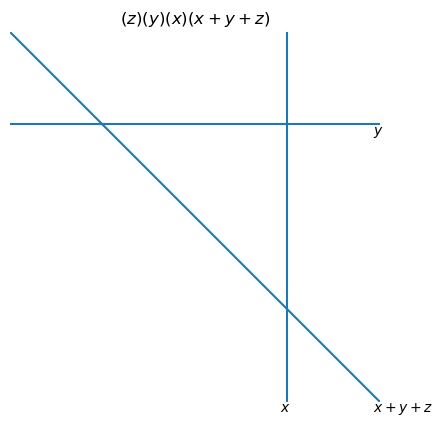

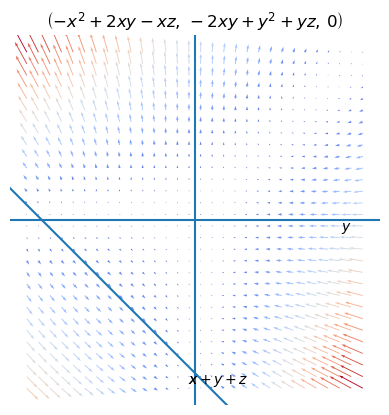

In [27]:
A.plot(xlim=(-1.5,0.5),ylim=(-1.5,0.5))
rv = vector((x*(y-z), y*(z-x), z*(x-y)))
A.plot(u=rv)

<IPython.core.display.Math object>

True
True
True


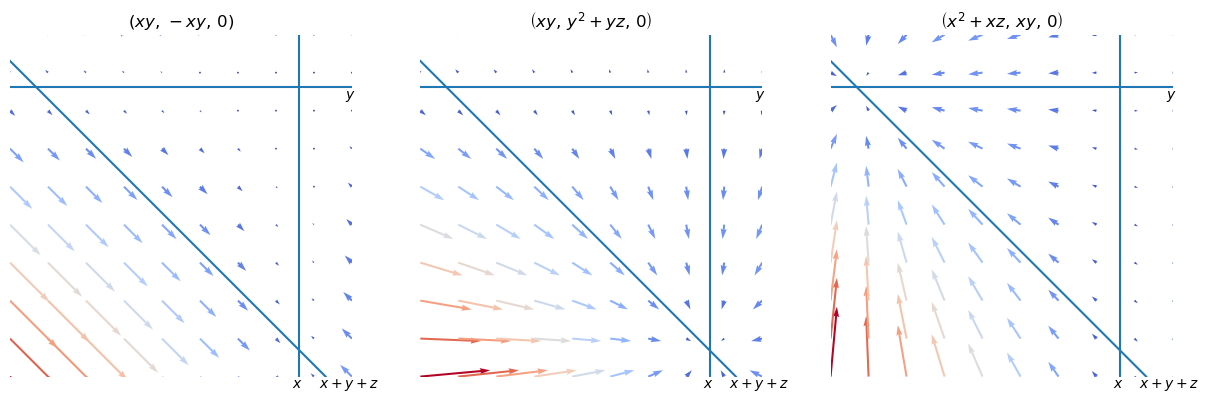

In [28]:
show(A.free_resolution())
MG=A.minimal_generators()[1:]
MG = [vector((x*y,-x*y,0)), vector((0,y*z,-y*z)), vector((x*z,0,-x*z))]

fig,axs = plt.subplots(1,len(MG),figsize=(5*len(MG),5))
for i,u in enumerate(MG):
    print(A.is_in_DA(u))
    A.plot(u,nx=10,ny=10,xlim=(-1.1,0.2),ylim=(-1.1,0.2),ax=axs[i],quiver=True)

## dim 3, |A|=4, non-free, SPOG

In [29]:
# the default base field is QQ
mat = [[1,0,0],[0,1,0],[0,0,1],[1,1,1]]
A=HyperPlaneArr(mat)
show(matrix(mat))
show(A.minimal_generators)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [30]:
# we can define the arrangement also by the defining polynomial
R.<x,y,z> = QQ['x,y,z']
A=HyperPlaneArr(Q=x*y*z*(x+y+z))
show(A.mat)
# check if generators are indeed in D(A)
for gv in A.minimal_generators():
    show(gv,A.is_in_DA(gv))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [31]:
# Free resolution
res=A.free_resolution()
print(ascii_art(res.chain_complex()))
res

                                                                              
            [              x               0               0               0] 
            [              y x*y + y^2 + y*z            -y*z             y*z] 
            [              z               0             y*z       x*z + z^2] 
 0 <-- C_0 <------------------------------------------------------------------

      [     0]      
      [    -z]      
      [-x - z]      
      [     y]      
 C_1 <--------- C_2 <-- 0 


S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-2)⊕S(-2)⊕S(-2) <-- S(-3) <-- 0

In [32]:
# the column vectors of the first differential corresponds to the generators
MG=[vector(u) for u in res.differential(1).matrix().columns()]
show(MG)


<IPython.core.display.Math object>

In [33]:
# the second differential gives the relation between the generators
# So, the following should be zero
matrix(MG).T * res.differential(2).matrix()


[0]
[0]
[0]

In [34]:
# This arrangement is SPOG
S = MG[0].parent().base_ring()
v = S.gens()

(c,i),RHS=A.level_coeff()
show((c,i),"\n",RHS)
show(c*A.minimal_generators()[i]-sum(c*A.minimal_generators()[i] for c,i in RHS))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## deletion

In [2]:
mat=[[ 1,  0,  0,  0],
[ 0,  1,  0,  0],
[ 0,  0,  1,  0],
[-1,  1,  0,  0],
[-1,  0,  1,  0],
[ 0, -1,  1,  0],
[ 0,  0,  0,  1],
[ 0,  1, -1,  1],
[-1,  1, -1,  1],
[ 0,  0, -1,  1]]
A=HyperPlaneArr(mat)
print(f"Num of planes: {A.num_planes}, Deg. Seq. {A.degs}")
A.free_resolution()

Num of planes: 10, Deg. Seq. Cached version of <function HyperplaneArrangement.degs at 0x172d732e0>


S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-3)⊕S(-3) <-- 0

In [3]:
# compute minimal generators of the deletion D(A_I) (removing planes with indices specified by the list I)
I = [2,4,9]
M01=A.deletion(I).minimal_generators()
degseq(M01)

[1, 2, 2, 2]

### $Q_I D(A_I) = \bigcap_{i\in I} a_i D(A_i)$
deletion D(A_I) can also be computed by taking intersection

In [4]:
# compute intersection
M=[matrix([g * A.linear_forms()[i] for g in A.deletion([i]).minimal_generators()]) for i in I]
Mint = module_intersection(M)
#M01a = [g/(A.linear_forms[i]*A.linear_forms[j]) for g in module_intersection(matrix(M0),matrix(M1))]
degseq(list(Mint)) # degree shift by |I|

[4, 5, 5, 5]

## Splitting $D(A)=D_0(A)\oplus \langle \theta_E \rangle$ by the Euler derivation

In [5]:
A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1,1,1]])
# make 0-th coordinate to vanish except for the euler derivation
G1 = [A.euler()]+[A.euler_complement(g,0) for g in A.minimal_generators()[1:]]
show(G1)

<IPython.core.display.Math object>

## Ex4.36 of Orlik-Terao
free $\subset$ non-free $\subset$ free

In [6]:
#free
A=HyperPlaneArr(matrix(QQ,coord_vec(3)+[[1,1,-1],[1,1,0]]))
show(A.mat)
print("free?",A.is_free)
A.degs()

<IPython.core.display.Math object>

free? True


[1, 2, 2]

In [ ]:
#non-free
B = A.deletion([4])
show(B.mat)
print("free?",B.is_free)
B.degs()

<IPython.core.display.Math object>

free? False


[1, 2, 2, 2]

In [ ]:
#free
C = B.deletion([3])
show(C.mat)
print("free?",C.is_free)
C.degs()

<IPython.core.display.Math object>

free? True


[1, 1, 1]

## Restriction

In [7]:
A=HyperPlaneArr(matrix(QQ,[[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1],[1,1,1,1],[1,1,1,-1]]))
print("original arr")
show(A.mat)
B=A.restriction(4) # restriction on the 4th plane
print("restriction to 4th plane")
show(matrix(B.mat))
H=A.mat[4]
B=A.restriction(H) # restriction to H
print("restriction to 4th plane")
show(matrix(B.mat))
#print(A.minimal_generators)
#print(B.minimal_generators)

original arr


<IPython.core.display.Math object>

restriction to 4th plane


<IPython.core.display.Math object>

restriction to 4th plane


<IPython.core.display.Math object>

### Ziegler's restriction (multi-restriction)

In [9]:
# note that the indices will shift after deletion.
# so here we are removing H0 and then restricting to H2 in the original arr.
mat=[[ 1,  0,  0,  0],
[ 0,  1,  0,  0],
[ 0,  0,  1,  0],
[-1,  1,  0,  0],
[-1,  0,  1,  0],
[ 0, -1,  1,  0],
[ 0,  0,  0,  1],
[ 0,  1, -1,  1],
[-1,  1, -1,  1],
[ 0,  0, -1,  1]]
A=HyperPlaneArr(matrix(QQ,[[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1],[1,1,1,1],[1,1,1,-1]]))
print("initial arr")
show(A.mat)
print("degree sequence:", A.degs)

print("restricted arr")
B=A.restriction(3)
show(B.mat)
print("multiplicity:", B.multiplicity)
print("degree sequence of the usual-arr:", B.degs)
MG = B.compute_multi_minimal_generators()
print("degree sequence of the multi-arr:", degseq(MG))
show(MG)

initial arr


<IPython.core.display.Math object>

degree sequence: Cached version of <function HyperplaneArrangement.degs at 0x172d732e0>
restricted arr


<IPython.core.display.Math object>

multiplicity: [1, 1, 1, 2]
degree sequence of the usual-arr: Cached version of <function HyperplaneArrangement.degs at 0x172d732e0>
degree sequence of the multi-arr: [2, 2, 2, 2]


<IPython.core.display.Math object>

In [10]:
### deletion and restriction in a row
# note that the indices will shift after deletion.
# so here we are removing H0 and then restricting to H2 in the original arr.
B=A.deletion([0]).restriction(1)
print(B.multiplicity)
print(B.degs)
MG = B.compute_multi_minimal_generators()
degseq(MG), MG

[1, 1, 1, 1]
Cached version of <function HyperplaneArrangement.degs at 0x172d732e0>


([1, 1, 2],
 [(-x1, x1, 0), (x0 + x1, 0, x2), (x0^2 + 2*x0*x1 + x1^2 - x2^2, 0, 0)])

## Parametrised family of arrangements

In [11]:
#Ex: arr. is free iff b = -t
b=2
t2=3
for t in range(-5,5):
    try:
        A=HyperPlaneArr(coord_vec(3)+[[1,1,0],[b,0,1],[0,t,1],[0,t2,1]])
        res=A.free_resolution()
        print(f"t={t} free? {A.is_free}")
        print(res,"\n")
    except:
        print(f"t={t} contains duplicate planes")


t=-5 free? False
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0 

t=-4 free? False
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0 

t=-3 free? False
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0 

t=-2 free? True
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-3) <-- 0 

t=-1 free? False
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0 

t=0 contains duplicate planes
t=1 free? False
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0 

t=2 free? False
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0 

t=3 contains duplicate planes
t=4 free? False
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0 



## Over finite fields
the degree sequence changes depending on the base field: K=QQ or K=GF(2)

In [13]:
mat=[[1,0,0],[0,1,0],[0,0,1],[1,1,0],[1,1,1],[1,0,-1],[0,1,1]]
A=HyperPlaneArr(mat,base_field=QQ)
B=HyperPlaneArr(mat,base_field=GF(2))
A.degs(), B.degs()

([1, 3, 3], [1, 2, 4])

## Multiarrangements

## Visualisation of vector fields

### n=2

(-4) * (-2*x0 + x1) * x0 * (x0 + x1)


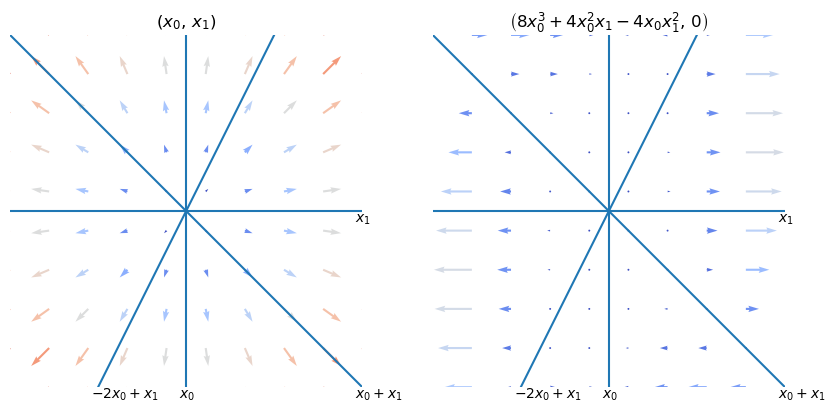

In [15]:
A=HyperPlaneArr([[1,0],[0,1],[1,1],[-2,1]])
MG = A.minimal_generators()
# MG is obtained by the splitting: Euler + {vect. field having no y-component}
print(factor(MG[1][0])) # this is a polynomial vanishing along all the planes
fig,axs = plt.subplots(1,len(MG),figsize=(5*len(MG),5))
for i,u in enumerate(MG):
    A.plot(u,nx=10,ny=10,xlim=(-2,2),ylim=(-2,2),ax=axs[i],quiver=True)

<Axes: title={'center': '$(x_{0})(x_{1})(x_{0} + x_{1})(-2 x_{0} + x_{1})$'}>

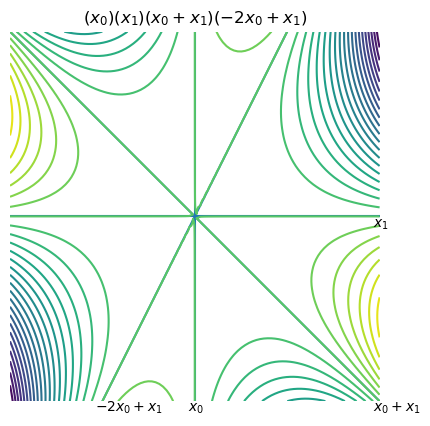

In [16]:
# contour of the defining polynomial
A.plot(levels=30,xlim=(-1,1),ylim=(-1,1))

### n=3

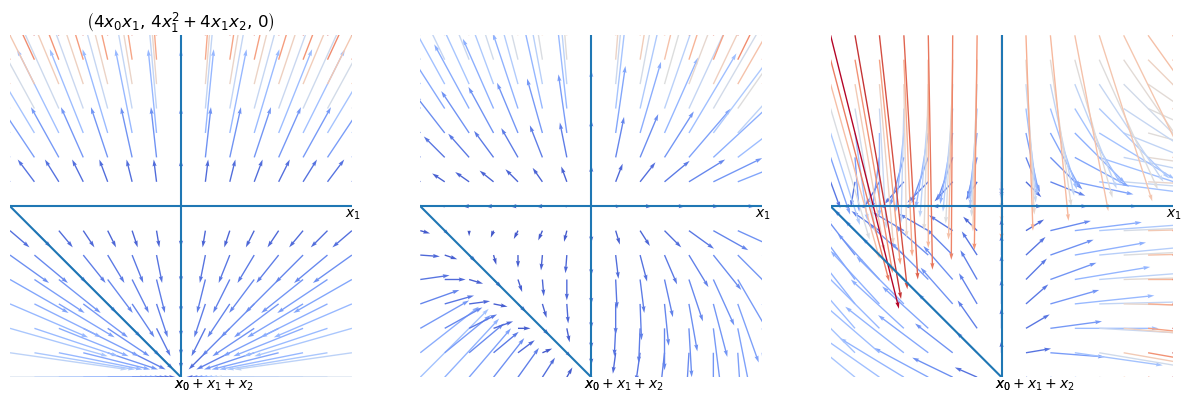

In [17]:
# for n=3, the z-component is made zero by the splitting
A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1,1,1]])
#A=matrix(K,[[1,0],[0,1],[1,1]])
MG = A.minimal_generators()[1:] # except for euler
fig,axs = plt.subplots(1,len(MG),figsize=(5*len(MG),5))
for i,u in enumerate(MG):
    A.plot(u,ax=axs[i],xlim=(-1,1),ylim=(-1,1),nx=15,ny=15,scale=10)


<Axes: title={'center': '$(x_{0})(x_{1})(x_{2})(x_{0} + x_{1} + x_{2})$'}>

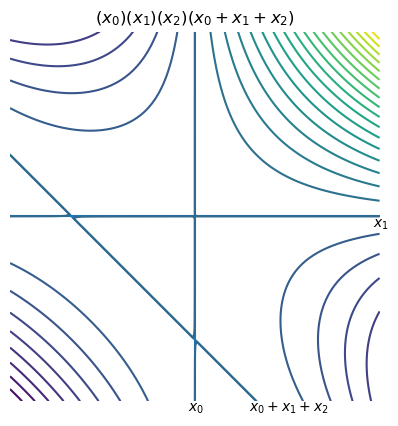

In [18]:
A.plot(levels=30,xlim=(-1.5,1.5),ylim=(-1.5,1.5))

## Large |MG| and max(deg(MG))

In [22]:
range_a = [11]
range_b = list(range(1,20))
n=3
max_num = 0
max_deg = 0
print('searching for A with large |MG| and max(deg)')
for b in tqdm(range_b):
    for a in range_a:
        mat=matrix(QQ,coord_vec(n)+[[1,1,1],[2,3,1],[3,4,1],[4,8,1],[5,11,1],[6,15,1],[7,9,1],[8,2,1],[9,5,1],[10,7,1],[a,b,1]])
        try:
            A=HyperPlaneArr(mat)
        except:
            continue
        MG = A.minimal_generators()
        if len(MG)>max_num:
            max_num=len(MG)
            print(f"(a,b)=({a},{b}), p={A.num_planes}, |MG|={max_num}")
        MG_dic = gendic(MG)
        if max(MG_dic.keys())>max_deg:
            max_deg = max(MG_dic.keys())
            print(f"(a,b)=({a},{b}), p={A.num_planes}, deg={max_deg}")


searching for A with large |MG| and max(deg)


  0%|          | 0/19 [00:00<?, ?it/s]

(a,b)=(11,1), p=14, |MG|=12
(a,b)=(11,1), p=14, deg=12
(a,b)=(11,3), p=14, |MG|=13
(a,b)=(11,10), p=14, |MG|=14


In [24]:
# this is a generic arrangement
# see https://www.sciencedirect.com/science/article/pii/002186939190052A?ref=pdf_download&fr=RR-2&rr=81815b587c4c17bb
n=3
mat=matrix(QQ,coord_vec(n)+[[1,1,1],[2,3,1],[3,4,1],[4,8,1],[5,11,1],[6,15,1],[7,9,1],[8,2,1],[9,5,1],[10,7,1],[11,10,1]])
for p in range(3,mat.nrows()+1):
    A = HyperPlaneArr(mat[:p,:])
    print(mat[:p,:].nrows(),degseq(A.minimal_generators()),len(A.minimal_generators()))
    print(A.free_resolution())


3 [1, 1, 1] 3
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-1)⊕S(-1) <-- 0
4 [1, 2, 2, 2] 4
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-2)⊕S(-2)⊕S(-2) <-- S(-3) <-- 0
5 [1, 3, 3, 3, 3] 5
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3) <-- S(-4)⊕S(-4) <-- 0
6 [1, 4, 4, 4, 4, 4] 6
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-4)⊕S(-4)⊕S(-4)⊕S(-4)⊕S(-4) <-- S(-5)⊕S(-5)⊕S(-5) <-- 0
7 [1, 5, 5, 5, 5, 5, 5] 7
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-5)⊕S(-5)⊕S(-5)⊕S(-5)⊕S(-5)⊕S(-5) <-- S(-6)⊕S(-6)⊕S(-6)⊕S(-6) <-- 0
8 [1, 6, 6, 6, 6, 6, 6, 6] 8
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-6)⊕S(-6)⊕S(-6)⊕S(-6)⊕S(-6)⊕S(-6)⊕S(-6) <-- S(-7)⊕S(-7)⊕S(-7)⊕S(-7)⊕S(-7) <-- 0
9 [1, 7, 7, 7, 7, 7, 7, 7, 7] 9
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-7)⊕S(-7)⊕S(-7)⊕S(-7)⊕S(-7)⊕S(-7)⊕S(-7)⊕S(-7) <-- S(-8)⊕S(-8)⊕S(-8)⊕S(-8)⊕S(-8)⊕S(-8) <-- 0
10 [1, 8, 8, 8, 8, 8, 8, 8, 8, 8] 10
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-8)⊕S(-8)⊕S(-8)⊕S(-8)⊕S(-8)⊕S(-8)⊕S(-8)⊕S(-8)⊕S(-8) <-- S(-9)⊕S(-9)⊕S(-9)⊕S(-9)⊕S(-9)⊕S(-9)⊕S(-9) <-- 0
11 [1, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9] 11
S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-9)⊕S(-9)⊕S(-9)⊕S(-9)⊕S(-9)

### max(deg) = p-n+1

In [26]:
n=8 # dimension
for p in range(n,n+10):
    mat=matrix(QQ,coord_vec(n)+[[2*t+1]+[1]*(n-1) for t in range(p-n)])
    try:
        A=HyperPlaneArr(mat)
    except:
        continue
    print(A.num_planes,A.degs(),A.num_planes-n+1)

8 [1, 1, 1, 1, 1, 1, 1, 1] 1
9 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2] 2
10 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3] 3
11 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4] 4
12 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 5, 5, 5, 5, 5, 5] 5
13 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6, 6, 6, 6, 6, 6, 6] 6
14 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 7, 7, 7, 7, 7, 7, 7] 7
15 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 8, 8, 8, 8, 8, 8, 8] 8
16 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 9, 9, 9, 9, 9, 9, 9] 9
17 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 10, 10, 10, 10, 10, 10, 10] 10


In [27]:
n=5 # dimension
for p in range(n,n+10):
    mat=matrix(QQ,coord_vec(n)+[[t]+[1]*(n-1) for t in range(1,p-n+1)])
    try:
        A=HyperPlaneArr(mat)
    except:
        continue
    print(A.num_planes,A.degs(),A.num_planes-n+1)

5 [1, 1, 1, 1, 1] 1
6 [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2] 2
7 [1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3] 3
8 [1, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4] 4
9 [1, 2, 2, 2, 2, 2, 2, 5, 5, 5, 5] 5
10 [1, 2, 2, 2, 2, 2, 2, 6, 6, 6, 6] 6
11 [1, 2, 2, 2, 2, 2, 2, 7, 7, 7, 7] 7
12 [1, 2, 2, 2, 2, 2, 2, 8, 8, 8, 8] 8
13 [1, 2, 2, 2, 2, 2, 2, 9, 9, 9, 9] 9
14 [1, 2, 2, 2, 2, 2, 2, 10, 10, 10, 10] 10


## Random arrangement
(speed comparison among different algorithms for D(A))

In [29]:
%%time
# Ex. random
p,n = 10,3
mat = remove_duplicate_planes(random_matrix(ZZ,p,n).change_ring(QQ))[0]
A = HyperPlaneArr(mat)
print("Number of planes:",A.num_planes)
show(A.mat)
A.degs(),p-n+1

Number of planes: 9


<IPython.core.display.Math object>

CPU times: user 40.6 ms, sys: 10.3 ms, total: 50.8 ms
Wall time: 79.8 ms


([1, 6, 7, 7, 7, 7, 7, 7], 8)

In [30]:
%%time
# this is slower
MG=min_gen_arr(mat,verbose=True)
degseq(MG)

Number of planes: 9
Number of vector generators at deg 1: 1
Number of vector generators at deg 2: 3
Number of vector generators at deg 3: 6
Number of vector generators at deg 4: 10
Number of vector generators at deg 5: 15
Number of vector generators at deg 6: 22
Number of vector generators at deg 7: 37
Number of vector generators at deg 8: 55
Degree sequence: [1, 6, 7, 7, 7, 7, 7, 7]
CPU times: user 1.49 s, sys: 105 ms, total: 1.6 s
Wall time: 1.51 s


[1, 6, 7, 7, 7, 7, 7, 7]

In [31]:
%%time
# this is slower
G = sum([basis_da(mat,k+1) for k in range(p-n+1)],[]) # module basis
MG = minimal_generating_set(G)
degseq(MG)

CPU times: user 1.44 s, sys: 76.7 ms, total: 1.52 s
Wall time: 1.41 s


[1, 6, 7, 7, 7, 7, 7, 7]

In [32]:
%%time
# this is slower
MG=min_gen_arr_linear(mat)
degseq(MG)

deg 1, num gens 1
deg 2, dim 3, codim 6, num new gen 0
deg 3, dim 6, codim 12, num new gen 0
deg 4, dim 10, codim 20, num new gen 0
deg 5, dim 15, codim 30, num new gen 0
deg 6, dim 22, codim 41, num new gen 1
deg 7, dim 37, codim 47, num new gen 6
CPU times: user 797 ms, sys: 43.9 ms, total: 841 ms
Wall time: 802 ms


[1, 6, 7, 7, 7, 7, 7, 7]

## Finding a free arrangement containing a given one

In [33]:
A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1,1,1]])
print(A.is_spog())
(c,i),RHS = A.level_coeff()
print(f"level coeff: {c}")
print(f"level gen: {A.minimal_generators()[i]}")
c*A.minimal_generators()[i], sum(c*A.minimal_generators()[i] for c,i in RHS) # these should be equal

[1, 2, 2, 2]
level coeff: x0 + 3*x2
level gen: (4*x0*x1, 4*x1^2 + 4*x1*x2, 0)


((4*x0^2*x1 + 12*x0*x1*x2, 4*x0*x1^2 + 4*x0*x1*x2 + 12*x1^2*x2 + 12*x1*x2^2, 0),
 (4*x0^2*x1 + 12*x0*x1*x2, 4*x0*x1^2 + 4*x0*x1*x2 + 12*x1^2*x2 + 12*x1*x2^2, 0))

In [34]:
# by symmetry, any permutation of [1,0,1] would make free addition
B=A.addition(vector([1,0,1]))
C=A.addition([1,1,0])
degseq(B.minimal_generators()),degseq(C.minimal_generators())

([1, 2, 2], [1, 2, 2])

In [40]:
# relations between generators
RM=Sequence([module_elem(A.S**A.n,tuple(A.minimal_generators()[i])) for i in range(1,len(A.minimal_generators()))])
G=syz(RM)
G

[(x0 + 3*x2, -x1 - 3*x2, -x1 + x2)]

In [41]:
# another example
A=HyperPlaneArr(identity_matrix(QQ,3).stack(matrix([[1 ,1, 0],[0 ,1, -1],[1 ,1, 1],[1 ,1, 2],[1,1,-2],[1,-1,0]])))
print(A.is_spog())
(c,i),RHS = A.level_coeff()
print(f"level coeff: {c}")
print(f"level gen: {A.minimal_generators()[i]}")


[1, 4, 5, 5]
level coeff: x0 - 7*x1 + 7*x2
level gen: (18*x0^4*x1 + 45*x0^3*x1^2 + 54*x0^2*x1^3 + 27*x0*x1^4 - 18*x0^4*x2 - 27*x0^3*x1*x2 - 9*x0^2*x1^2*x2 - 18*x0*x1^3*x2 - 18*x0^3*x2^2 - 117*x0^2*x1*x2^2 - 81*x0*x1^2*x2^2 + 72*x0^2*x2^3 + 72*x0*x2^4, 27*x0^3*x1^2 + 54*x0^2*x1^3 + 45*x0*x1^4 + 18*x1^5 - 27*x0^3*x1*x2 - 45*x0^2*x1^2*x2 - 9*x0^2*x1*x2^2 - 117*x0*x1^2*x2^2 - 90*x1^3*x2^2 + 72*x0*x1*x2^3 + 72*x1*x2^4, 0)


In [42]:
# adding the level coeff does not make it free
B=A.addition([-1,7,-7])
B.degs()

[1, 5, 6, 6, 7]

In [43]:
# search free addition: it seems there is a unique plane
plane = A.search_free_addition(a_range=range(-10,10),b_range=range(-10,10))

  0%|          | 0/20 [00:00<?, ?it/s]

plane:  (1, 1, -1) degrees:  [1, 4, 5]


In [44]:
# arrangement with no free addition
A=HyperPlaneArr(coord_vec(3)+[[1 ,1, 0],[1,3,1],[0 ,3, 1],[0 ,2, 1],[0,1,1],[0,1,-1],[0,1,2]])
A.degs()

[1, 3, 6]

In [45]:
# in this case, the level coeff ([-1,0,0]) is already in the arrangement
# this gives a counter-example to "SPOG => NT-free minus"
B=A.deletion([1,5])
print(B.is_spog())
(c,i),RHS = B.level_coeff()
print(f"level coeff: {c}")
print(f"level gen: {B.minimal_generators()[i]}")
B.free_resolution()


[1, 3, 5, 6]
level coeff: -x0
level gen: (96*x0*x1^5 - 64*x0^2*x1^3*x2 + 288*x0*x1^4*x2 - 128*x0^2*x1^2*x2^2 + 152*x0*x1^3*x2^2 + 64*x0^2*x1*x2^3 - 176*x0*x1^2*x2^3 + 128*x0^2*x2^4 - 248*x0*x1*x2^4 - 112*x0*x2^5, 96*x1^6 - 80*x0*x1^4*x2 + 272*x1^5*x2 - 200*x0*x1^3*x2^2 + 80*x1^4*x2^2 - 240*x1^3*x2^3 + 200*x0*x1*x2^4 - 176*x1^2*x2^4 + 80*x0*x2^5 - 32*x1*x2^5, 0)


S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-6)⊕S(-5) <-- S(-7) <-- 0

## Same lattice but different degree sequences
degree sequence is in general not combinatorial

S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-5)⊕S(-6)⊕S(-6) <-- S(-8) <-- 0


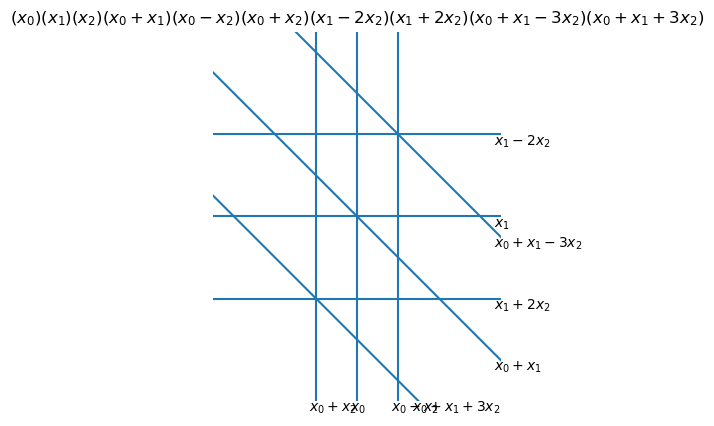

In [47]:
a=2
A=HyperPlaneArr(coord_vec(3)+[[1,1,0],[1,0,-1],[1,0,1],[0,1,-a],[0,1,2],[1,1,-a-1],[1,1,3]])
A.plot(xlim=(-3.5,3.5),ylim=(-4.5,4.5))
A.degs, latex(factor(A.Q),"\n")
print(A.free_resolution())

S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-6)⊕S(-6)⊕S(-6)⊕S(-6)⊕S(-6) <-- S(-7)⊕S(-7)⊕S(-7) <-- 0


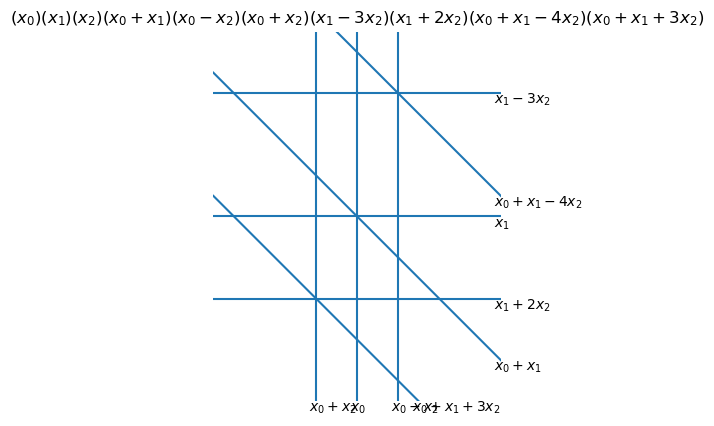

In [48]:
a=3
A=HyperPlaneArr(coord_vec(3)+[[1,1,0],[1,0,-1],[1,0,1],[0,1,-a],[0,1,2],[1,1,-a-1],[1,1,3]])
A.plot(xlim=(-3.5,3.5),ylim=(-4.5,4.5))
A.degs, latex(factor(A.Q),"\n")
print(A.free_resolution())

Cached version of <function HyperplaneArrangement.degs at 0x172d732e0>


  0%|          | 0/12 [00:00<?, ?it/s]

0 [1, 5, 5]
1 [1, 5, 5]
2 [1, 5, 6, 7]
3 [1, 5, 6, 7]
4 [1, 5, 6, 6]
5 [1, 5, 5]
6 [1, 5, 5]
7 [1, 5, 6, 6]
8 [1, 5, 5]
9 [1, 5, 5]
10 [1, 5, 6, 7]
11 [1, 5, 5]


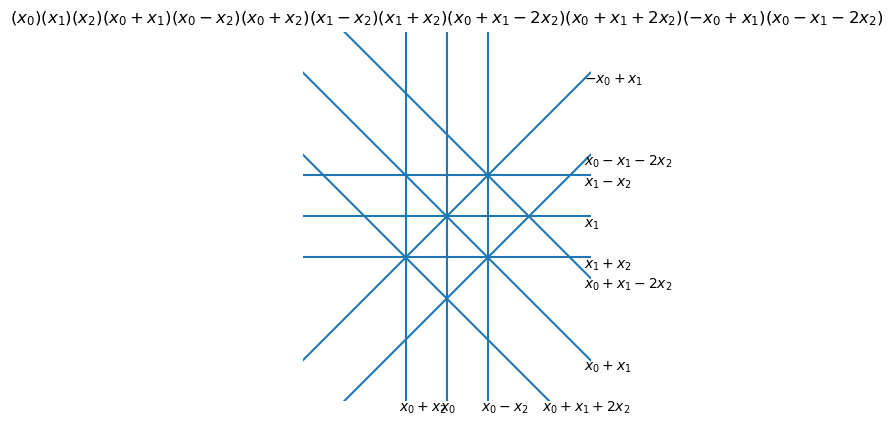

In [50]:
result1 = {}
a=1
mat=matrix(QQ,coord_vec(3)+[[1,1,0],[1,0,-1],[1,0,1],[0,1,-a],[0,1,1],[1,1,-a-1],[1,1,2],[-1,1,0],[1,-1,-2]])
A=HyperPlaneArr(mat)
A.plot(xlim=(-3.5,3.5),ylim=(-4.5,4.5))
print(A.degs)
for i in tqdm(range(mat.nrows())):
    B=A.deletion([i])
    result1[i]=B.degs()
    print(i,result1[i])

In [51]:
# Ziegler arrangements
M = [[0,1,0],[2,2,1],[3,1,1],[8,-1,4],[9,3,-1]]
A=HyperPlaneArr(M+[[9,-2,3],[11,2,1],[5,5,-2]],base_field=QQ)
B=HyperPlaneArr(M+[[21,-4,7],[19,4,1],[10,10,-5]],base_field=QQ)

A.degs(), B.degs()

([1, 5, 5, 5, 5], [1, 5, 5, 5, 5])

<Axes: title={'center': '$(x_{1})(2 x_{0} + 2 x_{1} + x_{2})(3 x_{0} + x_{1} + x_{2})(8 x_{0} - x_{1} + 4 x_{2})(9 x_{0} + 3 x_{1} - x_{2})(21 x_{0} - 4 x_{1} + 7 x_{2})(19 x_{0} + 4 x_{1} + x_{2})(10 x_{0} + 10 x_{1} - 5 x_{2})$'}>

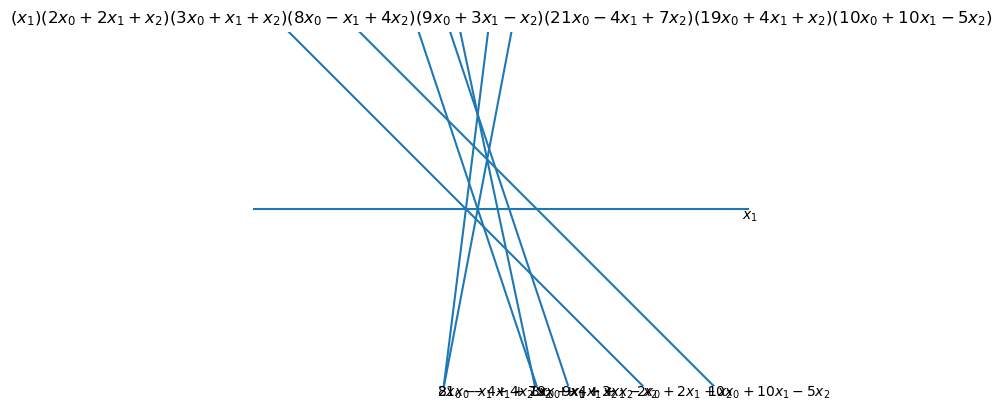

In [52]:
B.plot(xlim=(-3.5,3.5),ylim=(-2.5,2.5))


## Edelman-Reiner’s counter-example to Orlik's conjecture

In [53]:
mat=coord_vec(5)+[[1,1,1,1,1],[1,-1,1,1,1],[1,1,-1,1,1],[1,1,1,-1,1],[1,1,1,1,-1],[1,-1,-1,1,1],[1,-1,1,-1,1],[1,-1,1,1,-1],[1,-1,-1,1,-1],[1,-1,1,-1,-1],[1,-1,-1,-1,1],[1,1,-1,-1,1],[1,1,-1,1,-1],[1,1,-1,-1,-1],[1,1,1,-1,-1],[1,-1,-1,-1,-1]]
A=HyperPlaneArr(mat)

In [ ]:
res = list(sage.parallel.multiprocessing_sage.parallel_iter(int(0), list_ntf2, [((i,), {"A":A}) for i in range(A.num_planes-1)]))

In [ ]:
for i in range(A.num_planes):
    B=A.restriction(i)
    print(i,B.is_free)

In [ ]:
# list all minus-two
## restriction to both 0 and 2 are free, but minus {0,2} has more generators than dim+2
for i in range(A.num_planes):
    print(f"\nLooking at {i}-th plane")
    B=A.deletion([i])
    print(f"del {i} degrees: ",B.degs)
    C=A.restriction(i)
    print(f"Res to {i} free?: {C.is_free}, {C.degs}, is SPOG: {C.is_spog()},")
    if B.is_free:
        print(f"del {i} is free")


## free plus one can have a large PD

In [55]:
mat=coord_vec(5)+[[1,1,1,1,1]]
A=HyperPlaneArr(mat)
A.free_resolution()

S(0)⊕S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-2)⊕S(-2)⊕S(-2)⊕S(-2)⊕S(-2)⊕S(-2)⊕S(-2)⊕S(-2)⊕S(-2)⊕S(-2) <-- S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3) <-- S(-4)⊕S(-4)⊕S(-4)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0

In [56]:
mat=coord_vec(5)+[[1,1,1,1,1],[1,-1,1,1,1],[1,1,-1,1,1],[1,1,1,-1,1],[1,1,1,1,-1],[1,-1,-1,1,1],[1,-1,1,-1,1],[1,-1,1,1,-1],[1,-1,-1,1,-1],[1,-1,1,-1,-1],[1,-1,-1,-1,1],[1,1,-1,-1,1],[1,1,-1,1,-1]]
A=HyperPlaneArr(mat)
A.free_resolution()

S(0)⊕S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-4)⊕S(-4)⊕S(-5)⊕S(-5)⊕S(-5) <-- S(-6) <-- 0

# Experimental

## Term order and degrees of GB

In [57]:
A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1,1,1]])
Q=A.Q
R=Q.parent()
R.change_ring(order='degrevlex')
v=R.gens()
I = ideal(*[Q.derivative(v[j]) for j in range(A.n)],Q, order='deglex')
show(I)
show(I.groebner_basis())
R.term_order()


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Degree reverse lexicographic term order

In [58]:
show(I.syzygy_module())

<IPython.core.display.Math object>

In [ ]:
[f.lm() for f in I.groebner_basis()]

[x1^3*x2, x1^2*x2^2, x0^2*x1, x0^2*x2, x0*x1*x2]

pd=1 (1, 5) [1, 5, 5, 5, 5, 5, 7]
pd=1 (1, 6) [1, 5, 5, 5, 5, 5, 7]
pd=1 (1, 7) [1, 5, 5, 5, 5, 5, 7]
pd=1 (1, 8) [1, 5, 5, 5, 5, 5, 7]
